## **Project Name: "Smart City Deep Learning System"** ##

### **Module 1: Traffic Object Detection using YOLO.** ###

### **Install Required Libraries** ###

In [ ]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.6 MB/s eta 0:00:00


### **Mount Google Drive** ####

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### **Upload and Load Data into Colab** ###

In [ ]:
!mkdir -p traffic_yolo
!cp -r "/content/drive/MyDrive/Internship Projects DS/traffic_yolo/dataset" traffic_yolo/
!cp "/content/drive/MyDrive/Internship Projects DS/traffic_yolo/yolov8n.pt" traffic_yolo/
%cd traffic_yolo
!ls


/content/traffic_yolo
dataset  yolov8n.pt


In [ ]:
%cd /content/traffic_yolo
!ls


/content/traffic_yolo
dataset  yolov8n.pt


In [ ]:
!ls dataset
!ls dataset/train/images | wc -l


data.yaml  README.dataset.txt  README.roboflow.txt  train  valid
9230


## **YOLO Model Training** ##

In [ ]:
!yolo detect train \
  model=yolov8n.pt \
  data=dataset/data.yaml \
  epochs=12 \
  imgsz=512 \
  batch=24 \
  name=train3 \
  project="/content/drive/MyDrive/Internship Projects DS/traffic_yolo/runs" \
  cache=False \
  workers=2


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=24, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=12, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=Fal

### **Download YOLO Model and Results** ###

In [ ]:
from google.colab import files

files.download(
    "/content/drive/MyDrive/Internship Projects DS/traffic_yolo/runs/train3/weights/best.pt"
)
files.download(
    "/content/drive/MyDrive/Internship Projects DS/traffic_yolo/runs/train3/results.png"
)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **Predict Valid Images with Model and save it to predict file** ###

In [ ]:
!ls runs/detect


predict


In [ ]:
!ls runs/detect/predict


 bd_mp4-0_jpg.rf.8f931628bcdfbcacd7fd5df29aad05b8.jpg
 bd_mp4-3_jpg.rf.23390803fda039eb44d2a86bdca7602d.jpg
 car-10-_jpg.rf.fc2334bfc3dab414de55829589580ee3.jpg
 car-121-_jpg.rf.e63d481024d696a6e7a2ffb33e533b77.jpg
 car-124-_jpg.rf.fdc4e7eb371eea05a4ffad986aed1cac.jpg
 car-12-_jpg.rf.54c296ec96511c64286236d5611dfa98.jpg
 car-136-_jpg.rf.3a887b2a432ed6d0a704d081902967d2.jpg
 car-138-_jpg.rf.b2a0b303f1c0b823b1026ed59b7b4d63.jpg
 car-141-_jpg.rf.cb7eb09eb97a45d0fd436c54ca544188.jpg
 car-150-_jpg.rf.d4cd34b36aa58a0b908843bcc3e5b64c.jpg
 car-205-_jpg.rf.56d836f755d7dc1a845fb83efe254e17.jpg
 car-209-_jpg.rf.90c287c64986c1231963c863b519ca55.jpg
 car-216-_jpg.rf.47f4e3d8c82e48cda44df5278c34a043.jpg
 car-21-_jpg.rf.926b5b7810f7424d8db5f73d23316f6d.jpg
 car-224-_jpg.rf.fbc29e8001c51083141d4c3f8742dfc4.jpg
 car-230-_jpg.rf.de71a1dc3b182b0aa8e834d5e9b12b67.jpg
 car-231-_jpg.rf.bcafc547aa8cea8f8f379405f0d02615.jpg
 car-237-_jpg.rf.3465dbd500682ba0723b1185f4fda5f8.jpg
 car-241-_jpg.rf.ea9950b35d14f6

### **Download Few samples from Predict** ##

In [ ]:
from google.colab import files
import glob

imgs = glob.glob("runs/detect/predict/*.jpg")[:5]
for img in imgs:
    files.download(img)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Module 2: Complaint Classification using LSTM.** #

## **Mount Drive Again** ##

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Load Data** ##

In [ ]:
%cd "/content/drive/MyDrive/Internship Projects DS/Consumer Complaints Dataset"
!ls


/content/drive/MyDrive/Internship Projects DS/Consumer Complaints Dataset
clean_complaints.csv  Consumer_Complaints.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Consumer_Complaints.csv")
print(df.shape)
df.head()


(1025010, 19)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer Complaint,Company Public Response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date Sent to Company,Company Response to Consumer,Timely response?,Consumer disputed?,Complaint ID,Unnamed: 18
0,03-12-2014,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,M&T BANK CORPORATION,MI,48382,NaN,NaN,Referral,03/17/2014,Closed with explanation,Yes,No,759217,NaN
1,10-01-2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,NaN,Consent provided,Web,10-05-2016,Closed with explanation,Yes,No,2141773,NaN
2,10/17/2016,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,NaN,"CITIZENS FINANCIAL GROUP, INC.",PA,177XX,Older American,Consent provided,Web,10/20/2016,Closed with explanation,Yes,No,2163100,NaN
3,06-08-2014,Credit card,NaN,Bankruptcy,NaN,NaN,NaN,AMERICAN EXPRESS COMPANY,ID,83854,Older American,NaN,Web,06-10-2014,Closed with explanation,Yes,Yes,885638,NaN
4,09/13/2014,Debt collection,Credit card,Communication tactics,Frequent or repeated calls,NaN,NaN,"CITIBANK, N.A.",VA,23233,NaN,NaN,Web,09/13/2014,Closed with explanation,Yes,Yes,1027760,NaN


In [ ]:
df.columns


Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer Complaint', 'Company Public Response', 'Company', 'State',
       'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via',
       'Date Sent to Company', 'Company Response to Consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID',
       'Unnamed: 18'],
      dtype='object')

In [ ]:
# select correct columns
df = df[['Consumer Complaint', 'Product']]

# rename columns
df.rename(columns={
    'Consumer Complaint': 'text',
    'Product': 'label'
}, inplace=True)

print(df.shape)
df.head()


(1025010, 2)


,text,label
0,NaN,Mortgage
1,I have outdated information on my credit repor...,Credit reporting
2,I purchased a new car on XXXX XXXX. The car de...,Consumer Loan
3,NaN,Credit card
4,NaN,Debt collection


### **Data Cleaning** ###

### **Remove Null and Duplicates** ###

In [ ]:
# remove nulls
df.dropna(subset=['text', 'label'], inplace=True)

# remove empty text
df = df[df['text'].str.strip() != ""]

print("After removing null/empty:", df.shape)


After removing null/empty: (277814, 2)


/tmp/ipython-input-4188550651.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=['text', 'label'], inplace=True)


In [ ]:
df.drop_duplicates(subset=['text'], inplace=True)
print("After removing duplicates:", df.shape)


After removing duplicates: (268391, 2)


In [ ]:
df = df[df['text'].str.split().str.len() > 5]
print("After removing short complaints:", df.shape)


After removing short complaints: (267968, 2)


In [ ]:
# keep only 10000 samples for fast training
df = df.sample(10000, random_state=42)

print("Final dataset shape:", df.shape)
df['label'].value_counts()


Final dataset shape: (10000, 2)


,count
label,
Debt collection,2328
Mortgage,1617
"Credit reporting, credit repair services, or other personal consumer reports",1610
Credit reporting,1122
Credit card,693
Student loan,612
Bank account or service,536
Credit card or prepaid card,404
Consumer Loan,360


In [ ]:
df.to_csv("clean_complaints.csv", index=False)
print("Saved clean_complaints.csv")


Saved clean_complaints.csv


### **LOAD CLEAN DATASET** ###

In [ ]:
import pandas as pd

df = pd.read_csv("clean_complaints.csv")
print(df.shape)
df.head()


(10000, 2)


,text,label
0,Whoever is calling wanted to verify residency ...,Debt collection
1,Calls and voicemails everyday calling family m...,Debt collection
2,I changed my name more than a year ago. The ot...,Credit reporting
3,After checking my credit report I noticed that...,Debt collection
4,I am writing due to the continual harassing ac...,Mortgage


## **Label Encoding of Complaint Categories**
 **(LABEL ENCODING (TEXT → NUMBERS))**

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

num_classes = df['label_encoded'].nunique()
print("Number of classes:", num_classes)

# Save label mapping (important for inference & viva)
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
label_mapping


Number of classes: 17


{'Bank account or service': np.int64(0),
 'Checking or savings account': np.int64(1),
 'Consumer Loan': np.int64(2),
 'Credit card': np.int64(3),
 'Credit card or prepaid card': np.int64(4),
 'Credit reporting': np.int64(5),
 'Credit reporting, credit repair services, or other personal consumer reports': np.int64(6),
 'Debt collection': np.int64(7),
 'Money transfer, virtual currency, or money service': np.int64(8),
 'Money transfers': np.int64(9),
 'Mortgage': np.int64(10),
 'Other financial service': np.int64(11),
 'Payday loan': np.int64(12),
 'Payday loan, title loan, or personal loan': np.int64(13),
 'Prepaid card': np.int64(14),
 'Student loan': np.int64(15),
 'Vehicle loan or lease': np.int64(16)}

### **Text Tokenization and Sequence Padding** ###

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 12000   # vocabulary size
MAX_LEN = 150       # max complaint length

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['text'])

sequences = tokenizer.texts_to_sequences(df['text'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post')

y = df['label_encoded']

print(X.shape, y.shape)


(10000, 150) (10000,)


### **Train–Test Split** ###

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)


(8000, 150) (2000, 150)


### **BiLSTM Model Building, Training, Evaluation, and Saving** ###

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from sklearn.metrics import classification_report

model = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_length=MAX_LEN
    ),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

model.save("complaint_bilstm_model.h5")
print("complaint_bilstm_model.h5 saved successfully")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 60s 208ms/step - accuracy: 0.2313 - loss: 2.3773 - val_accuracy: 0.3610 - val_loss: 1.9258
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 55s 219ms/step - accuracy: 0.4123 - loss: 1.8071 - val_accuracy: 0.4895 - val_loss: 1.5742
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 85s 230ms/step - accuracy: 0.5367 - loss: 1.4270 - val_accuracy: 0.5360 - val_loss: 1.4304
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 77s 209ms/step - accuracy: 0.5835 - loss: 1.2123 - val_accuracy: 0.5220 - val_loss: 1.4756
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 85s 220ms/step - accuracy: 0.6269 - loss: 1.1319 - val_accuracy: 0.5790 - val_loss: 1.3440
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 81s 216ms/step - accuracy: 0.6786 - loss: 0.9349 - val_accuracy: 0.5650 - val_loss: 1.4122
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 216ms/step - accuracy: 0.7301 - loss: 0.7954 - val_accuracy: 0.5820 - val_loss: 1.3861
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 82s 218ms/step - accuracy: 0.7577 - loss: 0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                                                                              precision    recall  f1-score   support

                                                     Bank account or service       0.44      0.50      0.47       107
                                                 Checking or savings account       0.22      0.21      0.21        53
                                                               Consumer Loan       0.18      0.17      0.17        72
                                                                 Credit card       0.44      0.60      0.51       139
                                                 Credit card or prepaid card       0.20      0.14      0.16        81
                                                            Credit reporting       0.49      0.29      0.37       224
Credit reporting, credit repair services, or other personal consumer reports       0.52      0.58      0.55       322
                                                       

### **Saving Tokenizer.pkl and Label Encoder.pkl Model** ###

In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)


### **Testing The Complaints** ###

In [ ]:
def predict_complaint(text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN)
    pred = model.predict(padded)
    label = le.inverse_transform([pred.argmax()])
    return label[0]

predict_complaint("My credit card was charged twice without my permission")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


'Credit reporting, credit repair services, or other personal consumer reports'

# **Module 3: Energy Consumption Forecasting using LSTM/GRU.** #

### **Load Dataset** ###

In [ ]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/Internship Projects DS/Household Electric Power Consumption Dataset/household_power_consumption.txt"


In [ ]:
df = pd.read_csv(
    DATA_PATH,
    sep=';',
    na_values='?',
    low_memory=False
)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


### **Basic Dataset Info** ###

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   object 
 1   Time                   object 
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), object(2)
memory usage: 142.5+ MB


### **Check Missing Values** ###

In [ ]:
df.isna().sum()


,0
Date,0
Time,0
Global_active_power,25979
Global_reactive_power,25979
Voltage,25979
Global_intensity,25979
Sub_metering_1,25979
Sub_metering_2,25979
Sub_metering_3,25979


### **Convert Date + Time to Datetime** ###

In [ ]:
df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

df = df.drop(['Date', 'Time'], axis=1)
df.set_index('datetime', inplace=True)

df.head()


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [ ]:
df = df[['Global_active_power']]
df.head()


,Global_active_power
datetime,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666


In [ ]:
df.isna().sum()


,0
Global_active_power,25979


### **Data Cleaning and Preprocessing** ###

#### **Handle Missing Values** ####

In [ ]:
df = df.fillna(method='ffill')

df.isna().sum()


/tmp/ipython-input-3513722843.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,0
Global_active_power,0


In [ ]:
df_hourly = df.resample('H').mean()

print("Hourly dataset shape:", df_hourly.shape)
df_hourly.head()


Hourly dataset shape: (34589, 1)


/tmp/ipython-input-2229481867.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').mean()


,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


### **Visualize Data** ###

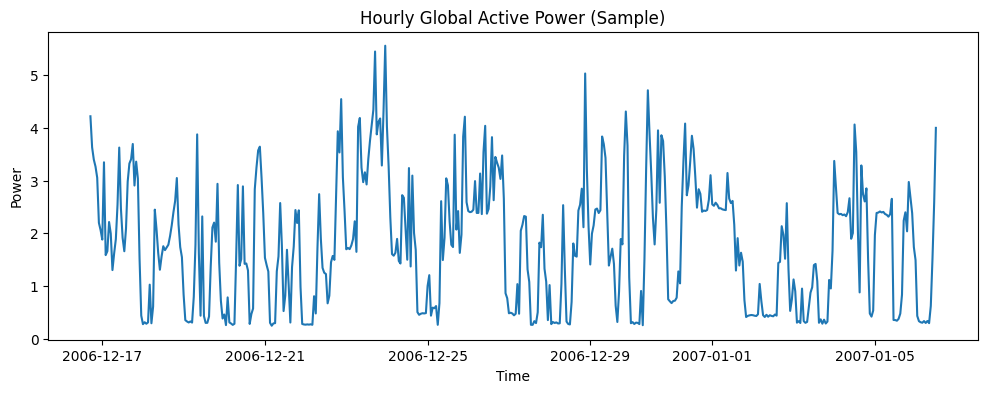

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df_hourly.index[:500], df_hourly['Global_active_power'][:500])
plt.title("Hourly Global Active Power (Sample)")
plt.xlabel("Time")
plt.ylabel("Power")
plt.show()


### **Save Clean Dataset** ###

In [ ]:
SAVE_PATH = "/content/drive/MyDrive/Internship Projects DS/Household Electric Power Consumption Dataset/clean_hourly_power.csv"

df_hourly.to_csv(SAVE_PATH)

print("Saved:", SAVE_PATH)


Saved: /content/drive/MyDrive/Internship Projects DS/Household Electric Power Consumption Dataset/clean_hourly_power.csv


#### **Load Clean Data** ####

In [ ]:
import pandas as pd
import numpy as np

DATA_PATH = "/content/drive/MyDrive/Internship Projects DS/Household Electric Power Consumption Dataset/clean_hourly_power.csv"

df_hourly = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
print(df_hourly.shape)
df_hourly.head()


(34589, 1)


,Global_active_power
datetime,
2006-12-16 17:00:00,4.222889
2006-12-16 18:00:00,3.632200
2006-12-16 19:00:00,3.400233
2006-12-16 20:00:00,3.268567
2006-12-16 21:00:00,3.056467


### **Normalize Data** ###

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_hourly)

scaled_data[:5]


array([[0.63681623],
       [0.54504495],
       [0.50900588],
       [0.48854974],
       [0.45559722]])

### **Create Sequences** ###

In [ ]:
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

SEQ_LEN = 24

X, y = create_sequences(scaled_data, SEQ_LEN)

print(X.shape, y.shape)


(34565, 24, 1) (34565, 1)


### **Train Test Data Split** ###

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(X_train.shape, X_test.shape)


(27652, 24, 1) (6913, 24, 1)


### **Build & Train LSTM** ###

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 18s 18ms/step - loss: 0.0149 - val_loss: 0.0069
Epoch 2/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.0103 - val_loss: 0.0068
Epoch 3/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - loss: 0.0096 - val_loss: 0.0063
Epoch 4/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.0095 - val_loss: 0.0063
Epoch 5/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.0089 - val_loss: 0.0061
Epoch 6/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.0088 - val_loss: 0.0062
Epoch 7/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0089 - val_loss: 0.0062
Epoch 8/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - loss: 0.0088 - val_loss: 0.0061
Epoch 9/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 0.0089 - val_loss: 0.0061
Epoch 10/10
865/865 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - loss: 0.0087 - val_loss: 0.0062
Test MSE: 0.006196608301252127
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


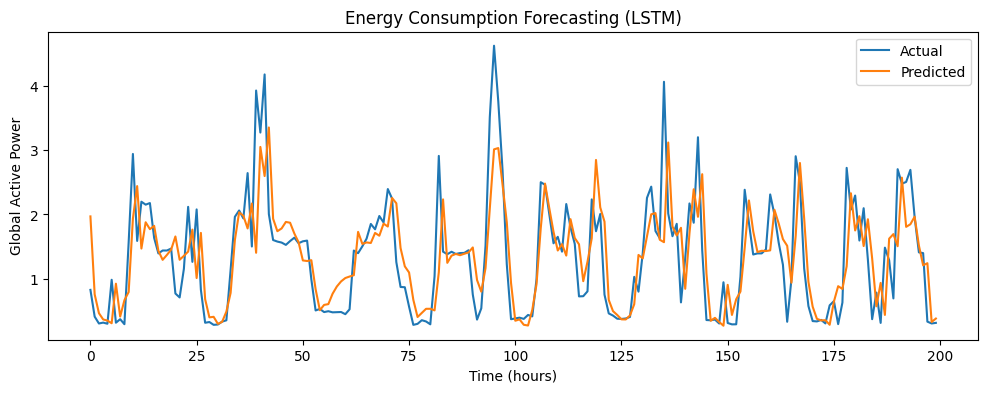

Saved: /content/drive/MyDrive/Internship Projects DS/Household Electric Power Consumption Dataset/energy_lstm_model.h5


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)
loss = model.evaluate(X_test, y_test, verbose=0)
print("Test MSE:", loss)
y_pred = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test_inv[:200], label="Actual")
plt.plot(y_pred_inv[:200], label="Predicted")
plt.title("Energy Consumption Forecasting (LSTM)")
plt.xlabel("Time (hours)")
plt.ylabel("Global Active Power")
plt.legend()
plt.show()
MODEL_PATH = "/content/drive/MyDrive/Internship Projects DS/Household Electric Power Consumption Dataset/energy_lstm_model.h5"

model.save(MODEL_PATH)
print("Saved:", MODEL_PATH)


